# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import tensorflow as tf
#from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Conv2D, MaxPooling2D, Flatten


# Load CIFAR-10 dataset
#(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
# Load the data from drive
data = np.load("/content/drive/MyDrive/cifar10.npz")

x_train = data["x_train"]
y_train = data["y_train"]
x_test = data["x_test"]
y_test = data["y_test"]

In [4]:
print(x_train.shape)
print(x_train.ndim)
print(x_test.shape)

(50000, 32, 32, 3)
4
(10000, 32, 32, 3)


In [5]:
print(y_train.shape)
print(y_train.ndim)
print(y_test.shape)

(50000, 1)
2
(10000, 1)


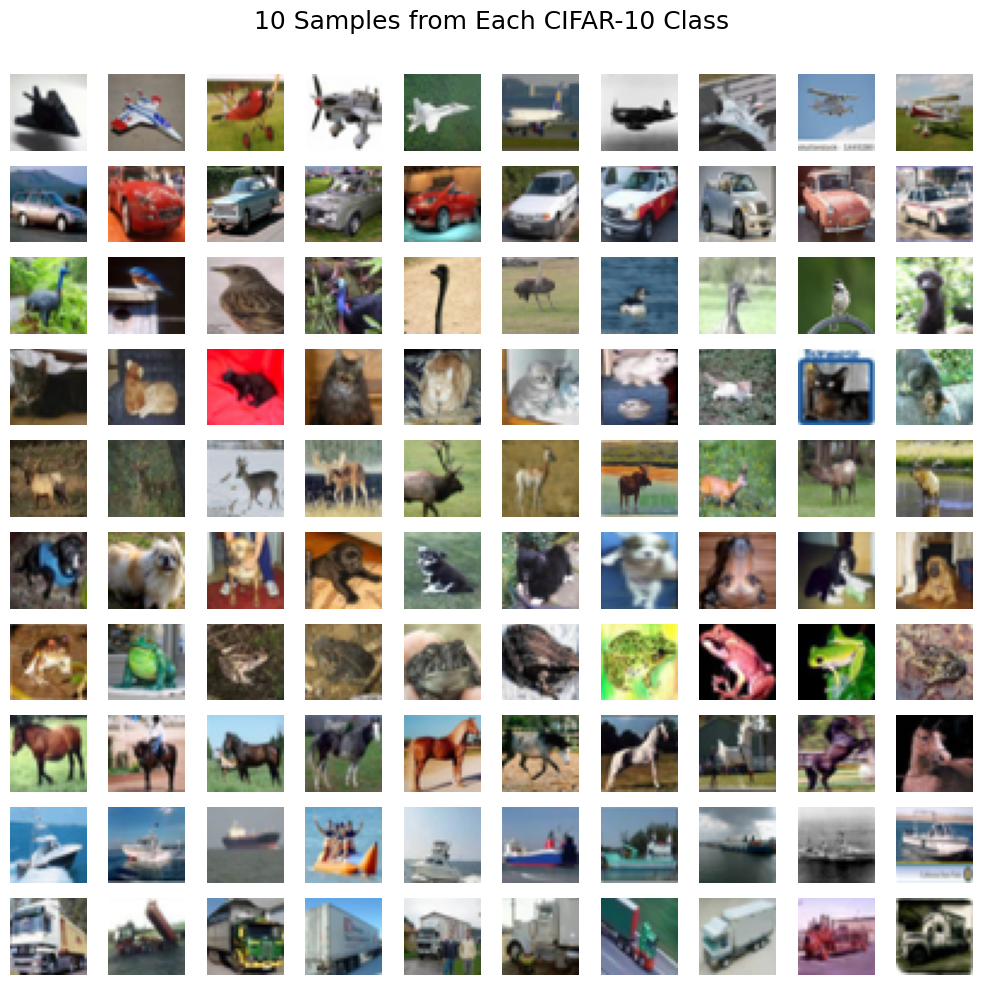

In [6]:
# Plot of 10 samples from each class
fig, axes = plt.subplots(10, 10, figsize=(10, 10))

for cls in range(10):
    # Get indices of images belonging to this class
    idx = np.where(y_train.flatten() == cls)[0][:10]
    for j, image_idx in enumerate(idx):
        axes[cls, j].imshow(x_train[image_idx])
        axes[cls, j].axis('off')

fig.suptitle("10 Samples from Each CIFAR-10 Class", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [7]:
# Data normalization
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [8]:
# Converting the labels to one-hot encoded form.
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [9]:
from keras.backend import clear_session
clear_session()

In [10]:
# Define model 1
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [11]:
# Compile model
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
# Train model
results = model.fit(x_train, y_train, batch_size=512, epochs=50)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.1935 - loss: 2.2444
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2839 - loss: 2.0889
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3160 - loss: 1.9709
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3350 - loss: 1.9106
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3475 - loss: 1.8727
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3589 - loss: 1.8381
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3699 - loss: 1.8069
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3787 - loss: 1.7810
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3861 - loss: 1.7578
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3950 - loss: 1.7327
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4037 - loss: 1.7102
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4

*   Plot the cross entropy loss curve and the accuracy curve

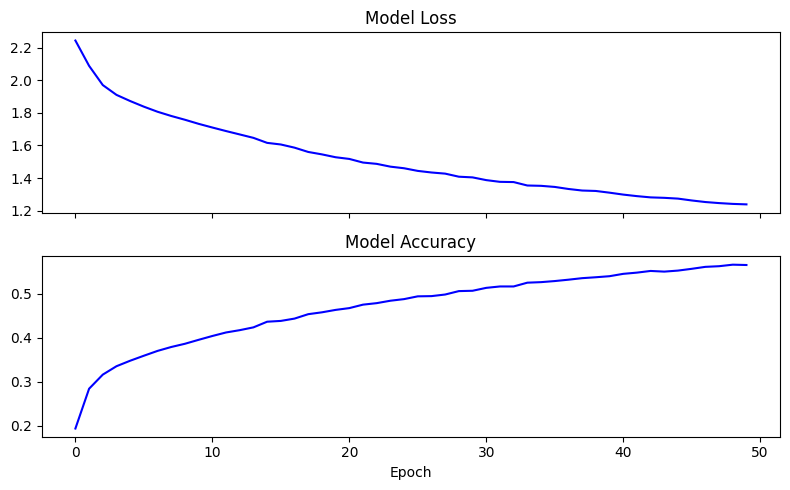

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(results.history['loss'], color='blue', label='Training Loss')
axes[0].set_title('Model Loss')

axes[1].plot(results.history['accuracy'], color='blue', label='Training Accuracy')
axes[1].set_title('Model Accuracy')

plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [13]:
from keras.backend import clear_session
clear_session()

In [14]:
# Define another deeper model_2

model_2 = Sequential()
model_2.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model_2.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D((2, 2)))
model_2.add(Flatten())
model_2.add(Dense(128, activation='relu'))
model_2.add(Dense(10, activation='softmax'))

model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [15]:
# Compile model_2
model_2.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
# Train model_2
results_2 = model_2.fit(x_train, y_train, batch_size=512, epochs=50)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.2091 - loss: 2.2199
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2806 - loss: 2.0499
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3124 - loss: 1.9615
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3376 - loss: 1.8969
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.3580 - loss: 1.8366
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3686 - loss: 1.7986
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3857 - loss: 1.7573
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3964 - loss: 1.7224
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4054 - loss: 1.6950
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4173 - loss: 1.6664
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4294 - loss: 1.6311
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy:

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


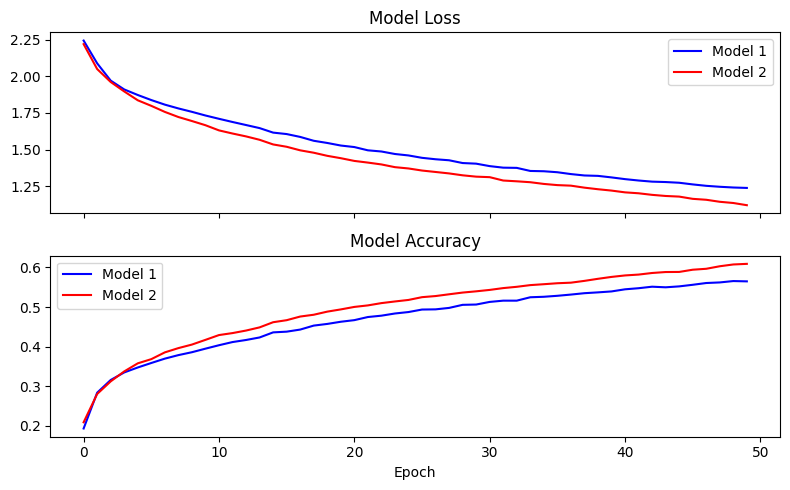

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(results.history['loss'], color='blue', label='Model 1')
axes[0].plot(results_2.history['loss'], color='red', label='Model 2')
axes[0].set_title('Model Loss')
axes[0].legend()

axes[1].plot(results.history['accuracy'], color='blue', label='Model 1')
axes[1].plot(results_2.history['accuracy'], color='red', label='Model 2')
axes[1].set_title('Model Accuracy')
axes[1].legend()

plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

**Comment on the observation**

- Yes, the deeper model (Model 2) performs better than Model 1.
- Adding one more convulutional layer extracts more features and helps the neural network learn high level features

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [17]:
# Predict with deeper model 2
predictions = model_2.predict(x_test)
print(predictions.shape)
cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(predictions, axis=1))
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
(10000, 10)
[[762  24  42  19  23   6  41  14  36  33]
 [ 87 628  17  10   9   6  27  13  24 179]
 [ 97   6 401  73 123  35 177  58  10  20]
 [ 33  12  69 425  84  78 227  48   6  18]
 [ 56   3 105  54 490  16 202  57   5  12]
 [ 28   5  76 267  97 296 138  78   6   9]
 [  9   8  41  39  54   5 821  11   4   8]
 [ 38   8  37  81  92  26  65 620   4  29]
 [260  54  15  36  23   3  23   9 508  69]
 [ 89 100  18  25   7   5  44  38  22 652]]


**Comment here :**

- Tha class confusion may be due to similiar feature being present in more than one class. Adding more convulutional layers may extract more specific features to each class and may improve the model.

*    Print the test accuracy for the trained model.

In [18]:
test_loss, test_acc = model_2.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5603 - loss: 1.2405
Test loss: 1.2404561042785645
Test accuracy: 0.5602999925613403


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [19]:
from keras.backend import clear_session
clear_session()

In [20]:
# Define another model_vgg

model_vgg = Sequential()
model_vgg.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64,3)))
model_vgg.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_vgg.add(MaxPooling2D((2, 2)))
model_vgg.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_vgg.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_vgg.add(MaxPooling2D((2, 2)))
model_vgg.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_vgg.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_vgg.add(MaxPooling2D((2, 2)))
model_vgg.add(Flatten())
model_vgg.add(Dense(128, activation='relu'))
model_vgg.add(Dense(10, activation='softmax'))

# Change input size
x_train = tf.image.resize(x_train, (64, 64))
x_test = tf.image.resize(x_test, (64, 64))

model_vgg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [21]:
# Compile model_vgg
model_vgg.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
# Train model_vgg
results_vgg = model_vgg.fit(x_train, y_train, batch_size=512, epochs=10)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 108s 696ms/step - accuracy: 0.1477 - loss: 2.2986
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 394ms/step - accuracy: 0.1683 - loss: 2.2838
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 394ms/step - accuracy: 0.2157 - loss: 2.2018
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 395ms/step - accuracy: 0.2511 - loss: 2.0808
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 396ms/step - accuracy: 0.2949 - loss: 1.9970
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 397ms/step - accuracy: 0.3228 - loss: 1.9283
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 397ms/step - accuracy: 0.3390 - loss: 1.8682
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 397ms/step - accuracy: 0.3603 - loss: 1.8104
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 398ms/step - accuracy: 0.3792 - loss: 1.7550
Epoch 10/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 398ms/step - accuracy: 0.3990 - loss: 1.7093


In [22]:
# Predict with deeper model 2
predictions_vgg = model_vgg.predict(x_test)
print(predictions_vgg.shape)
cm_vgg = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(predictions_vgg, axis=1))
print(cm_vgg)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
(10000, 10)
[[163  50 195  32  19  43  35 177 157 129]
 [  2 496   8  25   7  30  90 114  29 199]
 [  8  39 255  83 138  67 216 153  16  25]
 [  1  35  58 183  65 170 262 155  15  56]
 [  7  10  81  46 321  53 283 159  14  26]
 [  2  20  67 125  69 326 183 172  14  22]
 [  0  15  49  48 102  27 672  56   4  27]
 [  2  27  33  35  75  61  73 636  14  44]
 [ 24  73  18  40   6  51  29  91 426 242]
 [  4 147   9  26   3  27  75 138  35 536]]


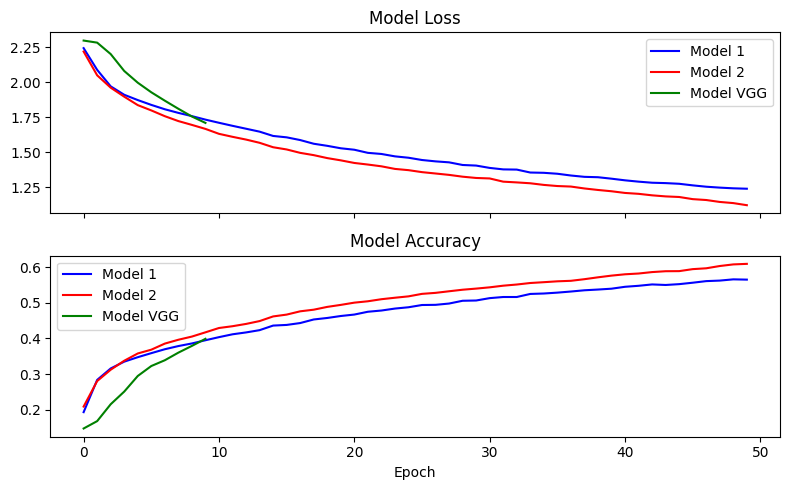

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(results.history['loss'], color='blue', label='Model 1')
axes[0].plot(results_2.history['loss'], color='red', label='Model 2')
axes[0].plot(results_vgg.history['loss'], color='green', label='Model VGG')
axes[0].set_title('Model Loss')
axes[0].legend()

axes[1].plot(results.history['accuracy'], color='blue', label='Model 1')
axes[1].plot(results_2.history['accuracy'], color='red', label='Model 2')
axes[1].plot(results_vgg.history['accuracy'], color='green', label='Model VGG')
axes[1].set_title('Model Accuracy')
axes[1].legend()

plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:
- Activation functions are used to introduce non-linearity in the neural network model. It is needed to learn complex patterns from the data.


_

2 - Key Differences between sigmoid and softmax:
-Sigmoid activation is used for binary classification models. It returns the probability of class.
- Softmax activation is used for multi-class classification models. It returns the probabilities of all class that summ to 1.


_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:
- Binary crossentropy loss function is used with sigmoid activation function for binary classification. It retuen a single probabilty and penalizes difference between true label and predicted probability.
- Categorical crossentropy is used with softmax activation and returns the probability of each class. It penalizes the difference between true label and predicted class with highest probability.

_
